# Fashion-MNIST 候选标签可视化

读取实验配置，按当前项目的真实数据划分与候选标签生成逻辑，展示 `noise_level=0.5` 下样本图像、真实标签和候选标签集合。


In [22]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms

REPO_ROOT = Path('/home/yxf/proj')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import common
import model
from client import Client
from common import ExperimentConfig


In [23]:
config_path = REPO_ROOT / '/home/yxf/proj/configs/vote/full/config_vote10_r200_s42.yaml'
client_id = 0
num_show = 16
random_seed = 42
sample_mode = 'random'  # 可选: 'random' 或 'head'

config = ExperimentConfig.from_yaml(str(config_path))
print(f'config: {config_path}')
print(f'dataset={config.dataset}, noise_level={config.noise_level}, uniform={config.uniform}, partition={config.partition}')


config: /home/yxf/proj/configs/vote/full/config_vote10_r200_s42.yaml
dataset=SVHN, noise_level=0.3, uniform=False, partition=non_iid


In [24]:
common.seed_everything(config.seed)

dataset_name = config.dataset.lower()
data_root = REPO_ROOT / 'data'

if dataset_name == 'fashionmnist':
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    try:
        train_dataset = datasets.FashionMNIST(root=str(data_root), train=True, transform=transform, download=False)
    except RuntimeError as e:
        raise RuntimeError(
            f'本地 Fashion-MNIST 数据不存在，请先确认数据已在 {data_root}/FashionMNIST 下。原始错误: {e}'
        )
elif dataset_name == 'svhn':
    mean = [0.4377, 0.4438, 0.4728]
    std  = [0.1980, 0.2010, 0.1970]
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    try:
        train_dataset = datasets.SVHN(root=str(data_root), split='train', transform=transform, download=False)
    except RuntimeError as e:
        raise RuntimeError(
            f'本地 SVHN 数据不存在，请先确认数据已在 {data_root}/SVHN 下。原始错误: {e}'
        )
else:
    raise ValueError(f'当前 notebook 仅支持 Fashion-MNIST 和 SVHN，got: {config.dataset}')

if config.partition.lower() == 'non_iid':
    client_datasets, client_indices, phi_matrix = common.non_iid_partition(
        train_dataset,
        num_clients=config.num_clients,
        num_classes=config.num_classes,
        p=config.p,
        alpha_dir=config.alpha_dir,
    )
else:
    client_datasets = common.iid_partition(train_dataset, num_clients=config.num_clients)
    client_indices = None
    phi_matrix = None

client_dataset = client_datasets[client_id]
base_model = model.get_model(config.model_name)
client = Client(base_model, client_dataset, client_id=client_id, config=config)

candidate_labels = client.train_plldataset.candidate_labels
if isinstance(candidate_labels, list):
    candidate_labels = torch.stack(candidate_labels)

print(f'dataset={dataset_name}')
print(f'client_id={client_id}, num_samples={len(client.train_plldataset)}')
print(f'candidate_labels shape={tuple(candidate_labels.shape)}')
print(f'candidate size mean={candidate_labels.sum(dim=1).float().mean().item():.3f}')



/home/yxf/miniconda3/envs/dl/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yxf/miniconda3/envs/dl/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/yxf/miniconda3/envs/dl/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Generating: 100%|██████████| 32/32

dataset=svhn
client_id=0, num_samples=4093
candidate_labels shape=(4093, 10)
candidate size mean=4.013


In [25]:
fashion_labels = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
svhn_labels = [str(i) for i in range(10)]

def denormalize_image(tensor, dataset_name):
    img = tensor.detach().cpu().clone()
    if dataset_name == 'fashionmnist':
        img = img * 0.3081 + 0.1307
        img = torch.clamp(img, 0, 1)
        return img.squeeze(0).numpy(), 'gray'
    if dataset_name == 'svhn':
        mean = torch.tensor([0.4377, 0.4438, 0.4728]).view(3, 1, 1)
        std = torch.tensor([0.1980, 0.2010, 0.1970]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        return img.permute(1, 2, 0).numpy(), None
    raise ValueError(f'Unsupported dataset: {dataset_name}')

def get_label_names(dataset_name):
    if dataset_name == 'fashionmnist':
        return fashion_labels
    if dataset_name == 'svhn':
        return svhn_labels
    raise ValueError(f'Unsupported dataset: {dataset_name}')

def candidate_indices(candidate_vector):
    return [int(i) for i, v in enumerate(candidate_vector.tolist()) if int(v) == 1]

label_names = get_label_names(dataset_name)
rng = random.Random(random_seed)
all_indices = list(range(len(client.train_plldataset)))
if sample_mode == 'random':
    sample_indices = rng.sample(all_indices, k=min(num_show, len(all_indices)))
else:
    sample_indices = all_indices[:min(num_show, len(all_indices))]

sample_indices



[2619,
 456,
 102,
 3037,
 1126,
 1003,
 914,
 571,
 3016,
 419,
 2771,
 3033,
 3654,
 2233,
 356,
 2418]

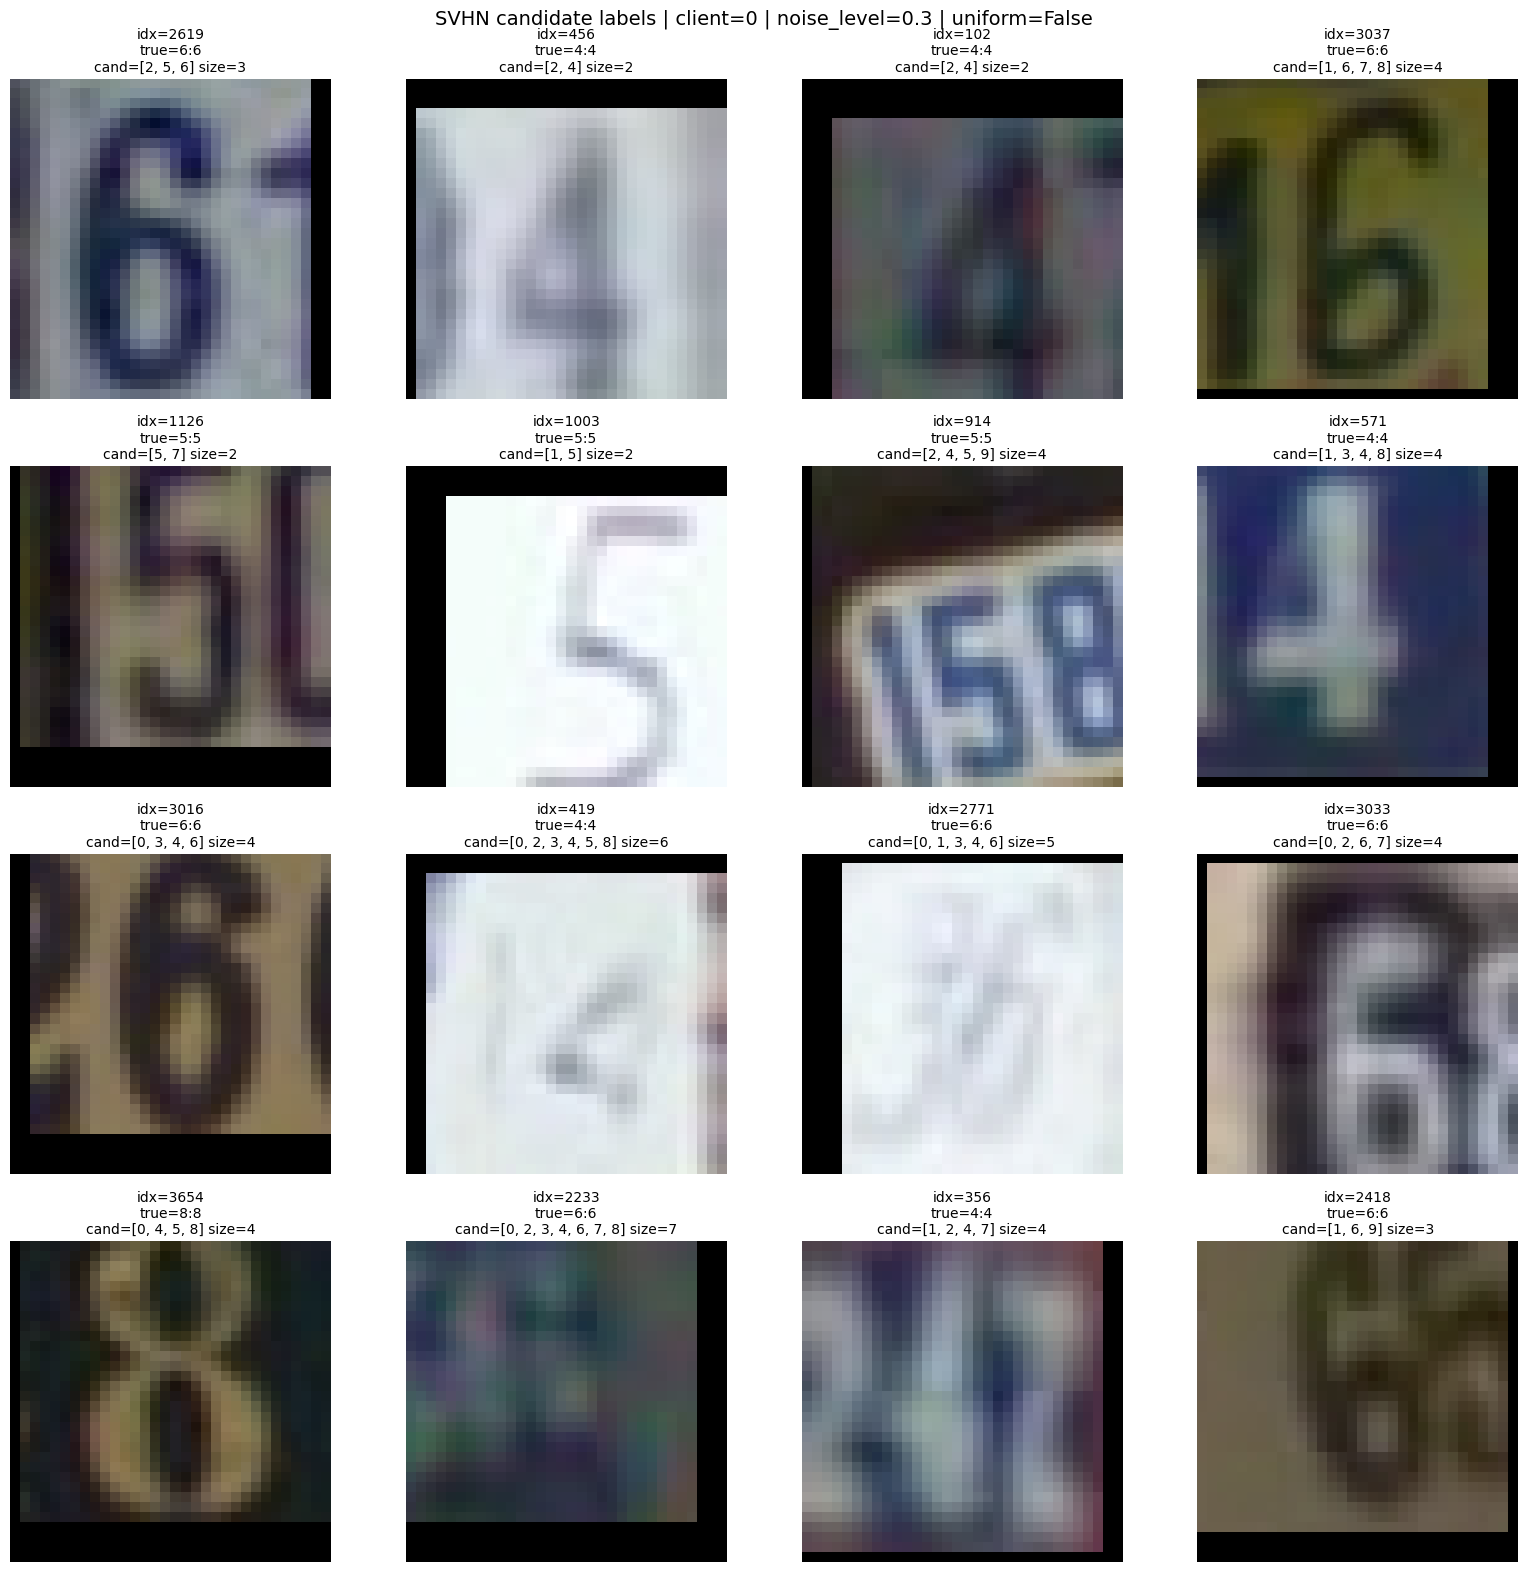

In [26]:
cols = 4
rows = int(np.ceil(len(sample_indices) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, sample_indices):
    image, true_label, candidate_vec, _ = client.train_plldataset[idx]
    image_np, cmap = denormalize_image(image, dataset_name)
    candidate_ids = candidate_indices(candidate_vec)

    if cmap is None:
        ax.imshow(image_np)
    else:
        ax.imshow(image_np, cmap=cmap)
    ax.axis('off')
    ax.set_title(
        f'idx={idx}\n'
        f'true={true_label}:{label_names[true_label]}\n'
        f'cand={candidate_ids} size={len(candidate_ids)}',
        fontsize=10
    )

for ax in axes[len(sample_indices):]:
    ax.axis('off')

fig.suptitle(
    f'{config.dataset} candidate labels | client={client_id} | noise_level={config.noise_level} | uniform={config.uniform}',
    fontsize=14
)
plt.tight_layout()
plt.show()



In [27]:
candidate_sizes = candidate_labels.sum(dim=1).cpu().numpy()
unique_sizes, counts = np.unique(candidate_sizes, return_counts=True)
for size, count in zip(unique_sizes.astype(int), counts.astype(int)):
    print(f'candidate_size={size}: {count}')


candidate_size=2: 480
candidate_size=3: 1024
candidate_size=4: 1199
candidate_size=5: 885
candidate_size=6: 385
candidate_size=7: 99
candidate_size=8: 21
